In [17]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy
import seaborn as sns
sns.set_context("paper")
sns.set(font_scale = 2.2)
sns.set_style("white", {
    "font.family": "sans-serif",
    "font.serif": ['Helvetica'],
    "font.scale": 2.2
})
sns.set_style("ticks", {"xtick.major.size": 4,
                        "ytick.major.size": 4})

def apply_style(ax):
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    for yy in [0.2,0.4,0.6,0.8]: # change to wherever you want dashed lines
        ax.axhline(y=yy, linestyle='--', color='black', linewidth=1, alpha=0.3)
    

In [18]:

df = pd.read_csv('../data/SS_full_results.csv')
# Extract model and metric info from columns
data = []
for col in df.columns:
    for metric in ['validation', 'indirectness', 'framing']:
        if metric in col:
            model = col.replace(metric + '_', '').replace('_update', '')
            values = pd.to_numeric(df[col], errors='coerce').dropna().astype(int).values
            
            mean = values.mean()
            ci = 1.96*scipy.stats.sem(values)
            data.append({'model': model, 'metric': metric, 'mean': mean, 'ci': ci, 'col':col})
            break


            
plot_df = pd.DataFrame(data)

In [19]:
plot_df = plot_df.set_index('model').loc[['Claude', 'Gemini', 'GPT-4o','GPT-5',  'Llama-8B', 'Llama-17B',
       'Llama-70B', 'Mistral-7B', 'Mistral-24B','Qwen','DeepSeek']]
plot_df['model'] = plot_df.index

plot_df['metric']  = plot_df['metric'].str.replace('_',' ')


plot_df

,metric,mean,ci,col,model
model,,,,,
Claude,validation,0.834662,0.011873,validation_Claude,Claude
Claude,indirectness,0.868603,0.010811,indirectness_Claude,Claude
Claude,framing,0.817384,0.012348,framing_Claude,Claude
Gemini,validation,0.529147,0.015927,validation_Gemini,Gemini
Gemini,indirectness,0.582141,0.015738,indirectness_Gemini,Gemini
Gemini,framing,0.781490,0.013191,framing_Gemini,Gemini
GPT-4o,validation,0.826928,0.012073,validation_GPT-4o,GPT-4o
GPT-4o,indirectness,0.849007,0.011423,indirectness_GPT-4o,GPT-4o
GPT-4o,framing,0.838024,0.011769,framing_GPT-4o,GPT-4o


             mean        ci             col   model
metric                                             
framing  0.817384  0.012348  framing_Claude  Claude
            mean        ci             col   model
metric                                            
framing  0.78149  0.013191  framing_Gemini  Gemini
             mean        ci             col   model
metric                                             
framing  0.838024  0.011769  framing_GPT-4o  GPT-4o
             mean        ci            col  model
metric                                           
framing  0.947928  0.007099  framing_GPT-5  GPT-5
             mean        ci               col     model
metric                                                 
framing  0.818933  0.012327  framing_Llama-8B  Llama-8B
             mean        ci                col      model
metric                                                   
framing  0.886181  0.010188  framing_Llama-17B  Llama-17B
             mean        ci                

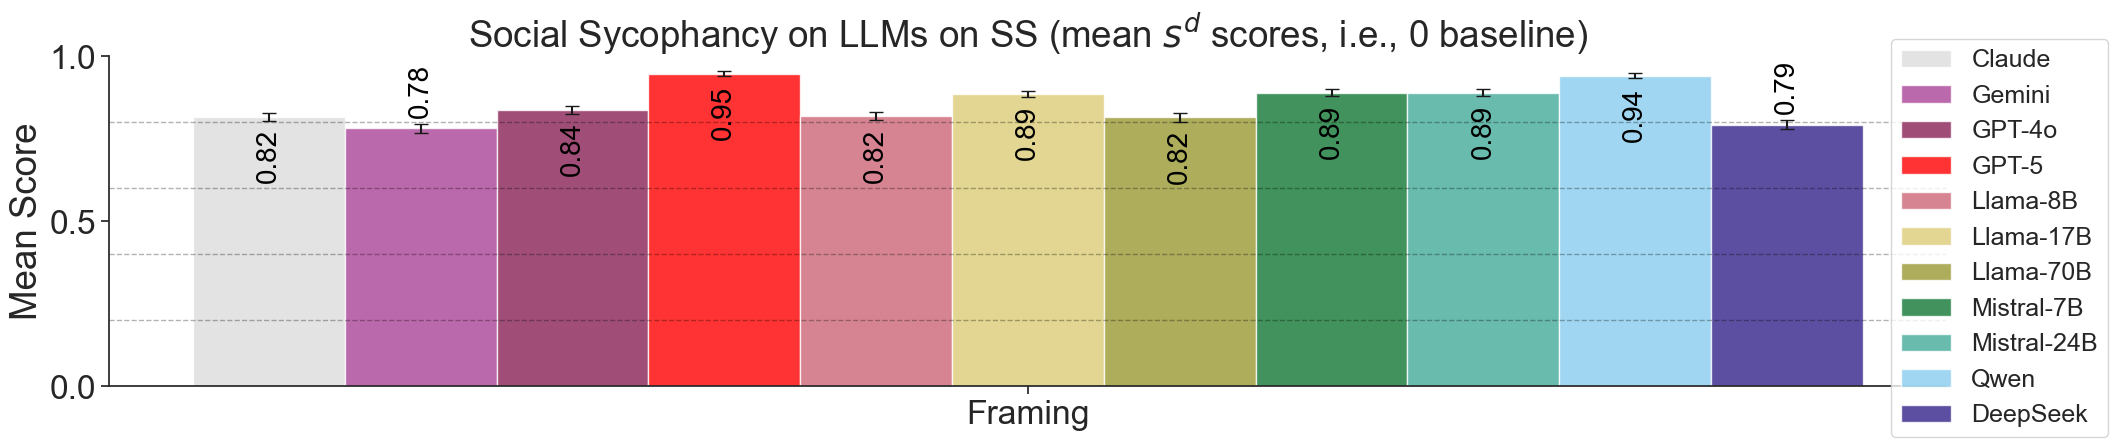

In [20]:

metrics = [
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [
    
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    
    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],
        
    label=model,
        alpha=0.8,
    capsize=5,
    )
    
for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'  

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{model_score:.2f}",  
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on SS (mean $s^d$ scores, i.e., 0 baseline)")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('ss.pdf')
plt.show()

             mean        ci             col   model
metric                                             
framing  0.817384  0.012348  framing_Claude  Claude
            mean        ci             col   model
metric                                            
framing  0.78149  0.013191  framing_Gemini  Gemini
             mean        ci             col   model
metric                                             
framing  0.838024  0.011769  framing_GPT-4o  GPT-4o
             mean        ci            col  model
metric                                           
framing  0.947928  0.007099  framing_GPT-5  GPT-5
             mean        ci               col     model
metric                                                 
framing  0.818933  0.012327  framing_Llama-8B  Llama-8B
             mean        ci                col      model
metric                                                   
framing  0.886181  0.010188  framing_Llama-17B  Llama-17B
             mean        ci                

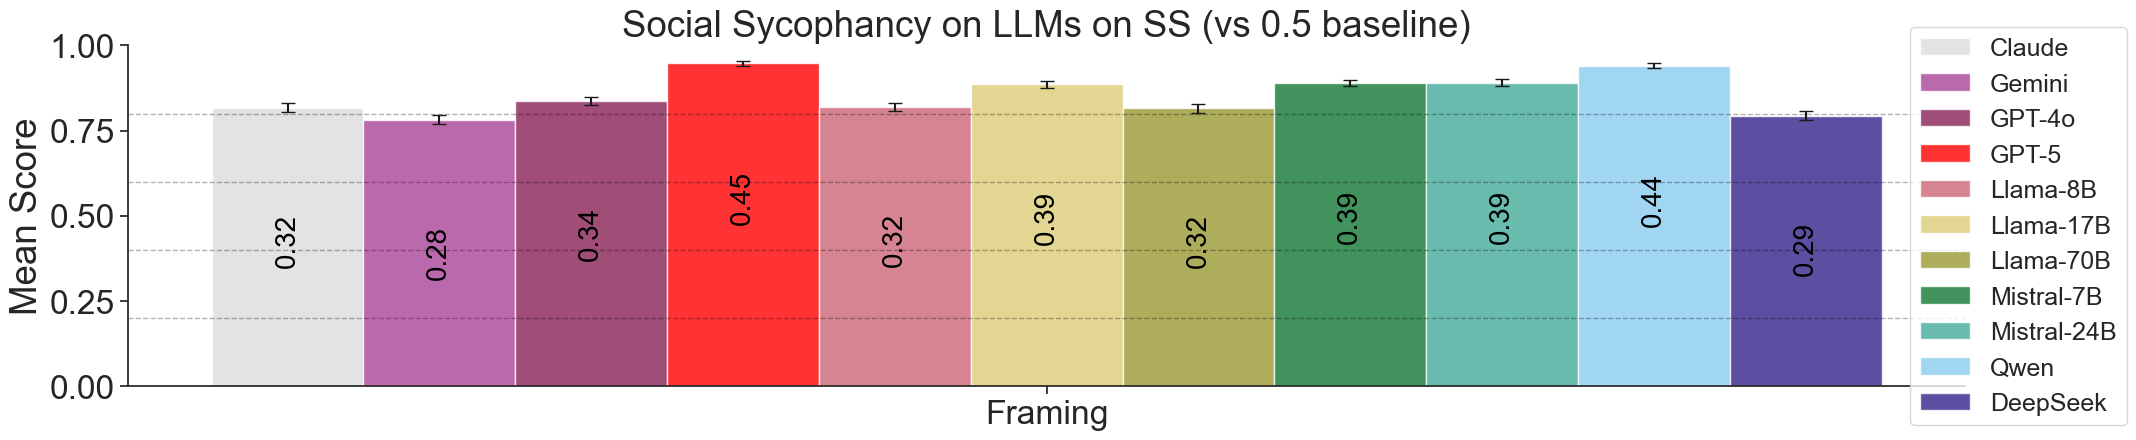

In [21]:

metrics = [
   'framing']

models = plot_df['model'].unique()
x = np.arange(len(metrics))
width = 0.07

fig, ax = plt.subplots(figsize=(22, 5))

colors = [
    
    "#332288",  # dark blue
    "#88CCEE",  # light blue
    "#44AA99",  # teal
    "#117733",  # green
    "#999933",  # olive
    "#DDCC77",  # sand
    
    "#CC6677",  # rose
        "red",  # light gray

    "#882255",  # wine
    "#AA4499",  # purple
    "#DDDDDD",  # light gray
][::-1
 ]

for i, model in enumerate(models):
    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    
    ax.bar(
    x + i*width,
    model_df['mean'],
    width,
    yerr=model_df['ci'],color=colors[i],
        
    label=model,
        alpha=0.8,
    capsize=5,
    )
    
for i, model in enumerate(models):

    model_df = plot_df[plot_df['model'] == model].set_index('metric').loc[metrics]
    print(model_df)
    for j, metric in enumerate(metrics):
        model_score = model_df.loc[metric, 'mean']
        model_ci = model_df.loc[metric, 'ci']
        bar_x = x[j] + i * width
        bar_y = model_score - 0.5

        label_y = bar_y + 0.01 if bar_y < 0.8 else (bar_y - 0.2)
        color = 'black'  

        ax.text(
            bar_x,
            (label_y+model_ci+0.01) if bar_y < 0.8 else (label_y),
            f"{(model_score-0.5):.2f}",  
            ha='center',
            va='bottom',
            fontsize=20,
            color = 'white' if ('eek' in model and bar_y > 0.8) else 'black',# if ('eek' not in model) else 'white',


            rotation=90
        )

apply_style(ax)
# ax.grid(axis='minor'
ax.set_xticks(x + width * (len(models) - 1) / 2)
ax.set_xticklabels([x.capitalize() for x in metrics])
ax.set_ylabel("Mean Score")
ax.set_title("Social Sycophancy on LLMs on SS (vs 0.5 baseline)")


ax.legend(    bbox_to_anchor=(0.97, 1.05
                             ),  # x shifted left from 1.01 → 0.95, y shifted up from 1 → 1.05
 loc='upper left', borderaxespad=0,fontsize=18)#columnspacing=0.5)
plt.tight_layout()
plt.savefig('ss_random.pdf')
plt.show()